#Fake News Detection using Traditional ML and ELECTRA



## Environment

In [2]:
!pip install -q "transformers>=4.40" "datasets>=2.19" evaluate scikit-learn accelerate

In [3]:
import os, re, random
import numpy as np, pandas as pd
import torch
import matplotlib.pyplot as plt

from datasets import Dataset
from transformers import (AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments,
                          Trainer, DataCollatorWithPadding, EarlyStoppingCallback, pipeline)

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.decomposition import TruncatedSVD
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support, roc_auc_score,
                             average_precision_score, roc_curve, precision_recall_curve,
                             confusion_matrix, ConfusionMatrixDisplay, classification_report)

SEED = 7
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)
if device != "cuda":
    print("WARNING: no GPU. ELECTRA fine-tuning needs one — enable it via "
          "Runtime > Change runtime type > GPU")

device: cuda



## 1) ISOT data

`True.csv` (Reuters) and `Fake.csv` (flagged outlets).  labelled as real = 1, fake = 0, and joining the headline
onto the body

In [4]:
def find_csv(name):
    for p in [name, f"data/{name}", f"/content/{name}", f"/content/data/{name}",
              f"/kaggle/input/fake-and-real-news-dataset/{name}"]:
        if os.path.exists(p):
            print("found:", p); return p
    raise FileNotFoundError(f"{name} not found — upload True.csv/Fake.csv into /content.")

true_df = pd.read_csv(find_csv("/content/True.csv")); true_df["label"] = 1
fake_df = pd.read_csv(find_csv("/content/Fake.csv")); fake_df["label"] = 0
for frame in (true_df, fake_df):
    frame["content"] = frame["title"].fillna("") + ". " + frame["text"].fillna("")

data = pd.concat([true_df[["content", "label"]], fake_df[["content", "label"]]], ignore_index=True)
data = data.sample(frac=1, random_state=SEED).reset_index(drop=True)
print(data["label"].value_counts().rename({0: "fake", 1: "real"}))

found: /content/True.csv
found: /content/Fake.csv
label
fake    23481
real    21417
Name: count, dtype: int64


## 2) Source-agnostic de-biasing

The ISOT dataset leaks its source:  To stop the model exploiting formatting instead of content, using
strip wire-service datelines, URLs, image-tweet links and @handles from *every* article.

In [5]:
AGENCY = re.compile(r"[A-Z][A-Za-z0-9.,'/\s]{0,60}\((Reuters|AP|AFP|Bloomberg)\)\s*[-\u2014]\s*")
URL    = re.compile(r"http\S+|www\.\S+|pic\.twitter\.com/\S+")
HANDLE = re.compile(r"@\w+")

def debias(text):
    text = AGENCY.sub("", text)
    text = URL.sub(" ", text)
    text = HANDLE.sub(" ", text)
    return re.sub(r"\s+", " ", text).strip()

leak_before = data["content"].str.contains(r"\(Reuters\)").mean()
data["content"] = data["content"].map(debias)
leak_after = data["content"].str.contains(r"\(Reuters\)").mean()
print(f"'(Reuters)' present before: {leak_before:.2%}  ->  after: {leak_after:.2%}")

'(Reuters)' present before: 47.34%  ->  after: 0.68%


## 3) Sub-sample and a 70 / 15 / 15 split

Using a clean three-way split — train / validation /
test

In [6]:
SAMPLE_SIZE = 16000
data, _ = train_test_split(data, train_size=SAMPLE_SIZE, stratify=data["label"], random_state=SEED)

train_df, tmp_df = train_test_split(data, test_size=0.30, stratify=data["label"], random_state=SEED)
val_df, test_df  = train_test_split(tmp_df, test_size=0.50, stratify=tmp_df["label"], random_state=SEED)
for name, frame in [("train", train_df), ("val", val_df), ("test", test_df)]:
    print(f"{name:5s} {len(frame):5d}  fake/real = {(frame.label==0).sum()}/{(frame.label==1).sum()}")

y_test = test_df["label"].values

train 11200  fake/real = 5858/5342
val    2400  fake/real = 1255/1145
test   2400  fake/real = 1255/1145


## 4) Classical baselines

Pipelines: a **Linear SVM** on word TF-IDF, and **latent semantic analysis
(TruncatedSVD) + Gradient Boosting**. Everything is trained only on the training split. `fake` is the
positive class throughout.

In [7]:
vectorizer = TfidfVectorizer(max_features=40000, ngram_range=(1, 2),
                             stop_words="english", sublinear_tf=True)
X_train = vectorizer.fit_transform(train_df["content"])
X_test  = vectorizer.transform(test_df["content"])

def score_model(name, y_true, y_pred, fake_score):
    """fake_score = higher means more likely FAKE (positive class)."""
    acc = accuracy_score(y_true, y_pred)
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="binary", pos_label=0)
    y_fake = (y_true == 0).astype(int)
    auc = roc_auc_score(y_fake, fake_score)
    ap  = average_precision_score(y_fake, fake_score)
    print(f"{name:24s} acc={acc:.4f}  F1={f1:.4f}  ROC-AUC={auc:.4f}  PR-AUC={ap:.4f}")
    return dict(model=name, accuracy=acc, precision=p, recall=r, f1=f1, roc_auc=auc, avg_precision=ap)

rows, curves = [], {}

# Linear SVM
svm = LinearSVC(C=1.0, random_state=SEED).fit(X_train, train_df["label"])
svm_fake = -svm.decision_function(X_test)          # flip sign: high => fake
rows.append(score_model("Linear SVM", y_test, svm.predict(X_test), svm_fake))
curves["Linear SVM"] = (roc_curve((y_test==0).astype(int), svm_fake),
                        precision_recall_curve((y_test==0).astype(int), svm_fake))

# LSA + Gradient Boosting
svd = TruncatedSVD(n_components=200, random_state=SEED)
Z_train, Z_test = svd.fit_transform(X_train), svd.transform(X_test)
gbm = HistGradientBoostingClassifier(max_iter=300, learning_rate=0.1, random_state=SEED)
gbm.fit(Z_train, train_df["label"])
gbm_fake = gbm.predict_proba(Z_test)[:, 0]         # P(fake)
rows.append(score_model("LSA + GBM", y_test, gbm.predict(Z_test), gbm_fake))
curves["LSA + GBM"] = (roc_curve((y_test==0).astype(int), gbm_fake),
                      precision_recall_curve((y_test==0).astype(int), gbm_fake))

Linear SVM               acc=0.9862  F1=0.9868  ROC-AUC=0.9986  PR-AUC=0.9989
LSA + GBM                acc=0.9750  F1=0.9761  ROC-AUC=0.9958  PR-AUC=0.9963


## 5) Tokenise for ELECTRA

The splits in Hugging Face `datasets` and tokenising with the ELECTRA WordPiece tokeniser. Padding
is deferred to a dynamic `DataCollatorWithPadding`, so each batch is padded only to its own longest
sequence.

In [8]:
MODEL_NAME = "google/electra-base-discriminator"
MAX_LEN = 320

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def to_dataset(frame):
    return Dataset.from_dict({"text": frame["content"].tolist(), "label": frame["label"].tolist()})

ds_train, ds_val, ds_test = to_dataset(train_df), to_dataset(val_df), to_dataset(test_df)

def tokenize(batch):
    return tokenizer(batch["text"], truncation=True, max_length=MAX_LEN)

ds_train = ds_train.map(tokenize, batched=True, remove_columns=["text"])
ds_val   = ds_val.map(tokenize,   batched=True, remove_columns=["text"])
ds_test  = ds_test.map(tokenize,  batched=True, remove_columns=["text"])
collator = DataCollatorWithPadding(tokenizer)

config.json:   0%|          | 0.00/666 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/11200 [00:00<?, ? examples/s]

Map:   0%|          | 0/2400 [00:00<?, ? examples/s]

Map:   0%|          | 0/2400 [00:00<?, ? examples/s]

## 6) Fine-tune with the `Trainer` API

`TrainingArguments` configures mixed-precision training, a warm-up, weight decay, per-epoch evaluation and
**best-checkpoint restore keyed on validation F1**.

In [9]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    probs = torch.softmax(torch.tensor(logits), dim=1).numpy()
    preds = probs.argmax(axis=1)
    p, r, f1, _ = precision_recall_fscore_support(labels, preds, average="binary", pos_label=0)
    return {"accuracy": accuracy_score(labels, preds), "precision": p, "recall": r, "f1": f1,
            "roc_auc": roc_auc_score((labels == 0).astype(int), probs[:, 0])}

model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2).to(device)

args = TrainingArguments(
    output_dir="electra-fakenews",
    num_train_epochs=3,
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    weight_decay=0.01,
    warmup_ratio=0.06,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    fp16=(device == "cuda"),
    logging_steps=50,
    report_to="none",
    seed=SEED,
)

import inspect
trainer_kwargs = dict(
    model=model, args=args,
    train_dataset=ds_train, eval_dataset=ds_val,
    data_collator=collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=1)],
)
if "processing_class" in inspect.signature(Trainer.__init__).parameters:
    trainer_kwargs["processing_class"] = tokenizer   # transformers >= 4.46 / v5
else:
    trainer_kwargs["tokenizer"] = tokenizer          # older transformers
trainer = Trainer(**trainer_kwargs)
trainer.train()

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  440MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] ElectraForSequenceClassification LOAD REPORT from: google/electra-base-discriminator
Key                                               | Status     | 
--------------------------------------------------+------------+-
discriminator_predictions.dense.weight            | UNEXPECTED | 
electra.embeddings_project.weight                 | UNEXPECTED | 
discriminator_predictions.dense_prediction.bias   | UNEXPECTED | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED | 
discriminator_predictions.dense.bias              | UNEXPECTED | 
electra.embeddings_project.bias                   | UNEXPECTED | 
classifier.out_proj.weight                        | MISSING    | 
classifier.dense.weight                           | MISSING    | 
classifier.dense.bias                             | MISSING    | 
classifier.out_proj.bias                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect ide

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Roc Auc
1,0.021168,0.006835,0.998750,0.999203,0.998406,0.998804,0.999989
2,0.000405,0.012210,0.997917,0.999201,0.996813,0.998006,0.999987


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1400, training_loss=0.05593920147312539, metrics={'train_runtime': 426.6296, 'train_samples_per_second': 78.757, 'train_steps_per_second': 4.922, 'total_flos': 3683554775040000.0, 'train_loss': 0.05593920147312539, 'epoch': 2.0})

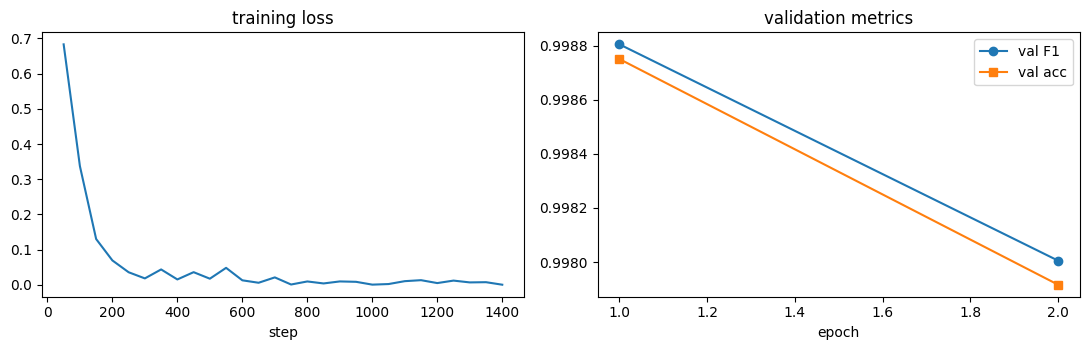

In [10]:
# Training curves from the Trainer log history
hist = pd.DataFrame(trainer.state.log_history)
tr_l = hist.dropna(subset=["loss"]); ev_l = hist.dropna(subset=["eval_loss"])
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].plot(tr_l["step"], tr_l["loss"], label="train"); ax[0].set_title("training loss"); ax[0].set_xlabel("step")
ax[1].plot(ev_l["epoch"], ev_l["eval_f1"], "-o", label="val F1")
ax[1].plot(ev_l["epoch"], ev_l["eval_accuracy"], "-s", label="val acc")
ax[1].set_title("validation metrics"); ax[1].set_xlabel("epoch"); ax[1].legend()
plt.tight_layout(); plt.show()

## 7) Evaluating ELECTRA on the held-out test set

In [11]:
pred = trainer.predict(ds_test)
probs = torch.softmax(torch.tensor(pred.predictions), dim=1).numpy()
y_pred = probs.argmax(axis=1)
fake_score = probs[:, 0]

rows.append(score_model("ELECTRA (fine-tuned)", y_test, y_pred, fake_score))
curves["ELECTRA"] = (roc_curve((y_test==0).astype(int), fake_score),
                    precision_recall_curve((y_test==0).astype(int), fake_score))
print()
print(classification_report(y_test, y_pred, target_names=["fake", "real"], digits=4))

ELECTRA (fine-tuned)     acc=0.9979  F1=0.9980  ROC-AUC=1.0000  PR-AUC=1.0000

              precision    recall  f1-score   support

        fake     1.0000    0.9960    0.9980      1255
        real     0.9957    1.0000    0.9978      1145

    accuracy                         0.9979      2400
   macro avg     0.9978    0.9980    0.9979      2400
weighted avg     0.9979    0.9979    0.9979      2400



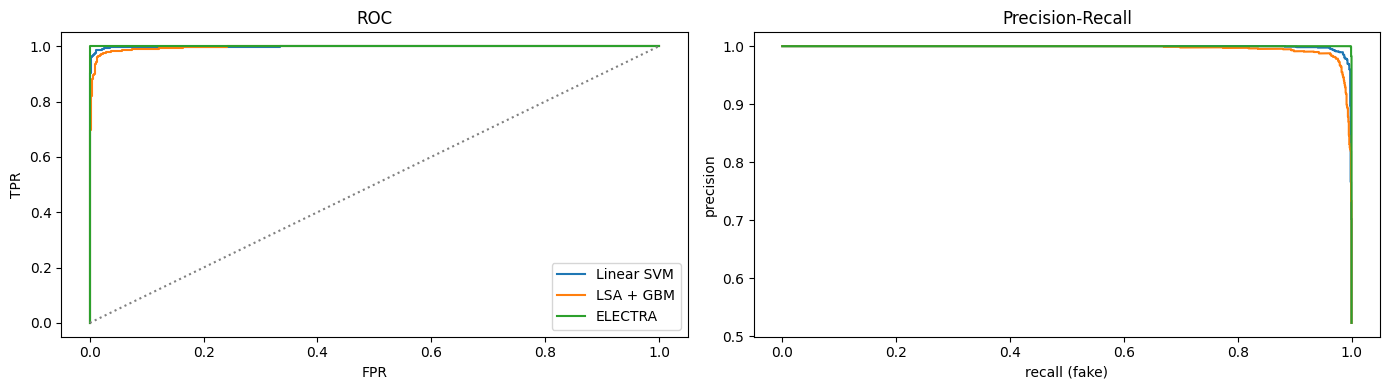

In [18]:
# ROC + PR curves for all models
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
for name, ((fpr, tpr, _), (prec, rec, _)) in curves.items():
    ax[0].plot(fpr, tpr, label=name); ax[1].plot(rec, prec, label=name)
ax[0].plot([0, 1], [0, 1], ":", color="grey"); ax[0].set_title("ROC"); ax[0].set_xlabel("FPR"); ax[0].set_ylabel("TPR"); ax[0].legend()
ax[1].set_title("Precision-Recall"); ax[1].set_xlabel("recall (fake)"); ax[1].set_ylabel("precision");
plt.tight_layout(); plt.show()

## 8) Model comparison

In [19]:
comparison = pd.DataFrame(rows).set_index("model").round(4)
comparison.to_csv("electra_comparison.csv")
comparison

,accuracy,precision,recall,f1,roc_auc,avg_precision
model,,,,,,
Linear SVM,0.9862,0.9888,0.9849,0.9868,0.9986,0.9989
LSA + GBM,0.9750,0.9753,0.9769,0.9761,0.9958,0.9963
ELECTRA (fine-tuned),0.9979,1.0000,0.9960,0.9980,1.0000,1.0000


## 9) Deployment

The fine-tuned model drops straight into a `transformers.pipeline`

In [20]:
classifier = pipeline("text-classification", model=model, tokenizer=tokenizer,
                      device=0 if device == "cuda" else -1, truncation=True, max_length=MAX_LEN)
LABELS = {"LABEL_0": "FAKE", "LABEL_1": "REAL"}

samples = [
    "The finance ministry said on Tuesday that growth had slowed to 1.8% in the last quarter.",
    "You WON'T BELIEVE what this senator did — the mainstream media is HIDING the shocking truth!!!",
]
for text in samples:
    out = classifier(text)[0]
    print(f"{LABELS.get(out['label'], out['label']):4s}  p={out['score']:.3f}  |  {text[:65]}...")

REAL  p=0.999  |  The finance ministry said on Tuesday that growth had slowed to 1....
FAKE  p=0.999  |  You WON'T BELIEVE what this senator did — the mainstream media is...
